In [1]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss


def adf_test(x):
    indices = ['ADF: Test statistic', 'p value', '# of Lags', '# of Observations']

    test = adfuller(x, autolag='AIC') # Perform

    #Dickey-Fuller test

    results = pd.Series(test[:4], index=indices)
    
    for key, value in test[4].items():

        results[f'Critical Value ({key})'] = value
        
    if results['p value'] <= 0.05: # (p-value < 0.05 (alpha=5%))

        print("Reject the null hypothesis (H0), \nthe data is stationary.")

    else:

        print("Fail to reject the null hypothesis (HO), \nthe data is not stationary.")
    
    return results

def kpss_test(x):
    indices = ['KPSS: Test statistic', 'p value', '# of Lags']

    test = kpss(x)

    results = pd.Series(test[:3], index=indices)

    for key, value in test[3].items():

        results[f'Critical Value ({key})'] = value

    if results['p value'] <= 0.05: # (p-value < 0.05 (alpha=5%))

        print("Reject the null hypothesis (H0), \nthe data is not stationary.")

    else:

        print("Fail to reject the null hypothesis (HO), \nthe data is stationary.")
    return results

    

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa. seasonal import seasonal_decompose
from statsmodels.graphics. tsaplots import plot_pacf, plot_acf


from statsmodels.tsa.arima.model import ARIMA

from pmdarima.arima import auto_arima
from sklearn. metrics import mean_squared_error

from sklearn. model_selection import train_test_split

import warnings
warnings. filterwarnings("ignore")

In [3]:
plt.rcParams['figure.figsize'] = (8,4)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['font.size'] = 14 

In [4]:
!pip freeze 

absl-py==2.3.1
aiohappyeyeballs==2.6.2
aiohttp==3.14.0
aiosignal==1.4.0
altair==6.1.0
annotated-types==0.7.0
anyio==4.10.0
appdirs==1.4.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.0
astunparse==1.6.3
async-lru==2.3.0
attrs==25.4.0
Babel==2.14.0
backoff==2.2.1
beautifulsoup4==4.14.2
bleach==6.2.0
blinker==1.9.0
brotli==1.2.0
browser-cookie3==0.20.1
bs4==0.0.2
cachetools==5.5.2
certifi==2025.8.3
cffi==2.0.0
charset-normalizer==3.4.3
click==8.2.1
cobble==0.1.4
colorama==0.4.6
comm==0.2.3
contourpy==1.2.1
conv==0.2
cryptography==46.0.5
cssselect==1.3.0
cssselect2==0.9.0
curl_cffi==0.15.0
cycler==0.12.1
Cython==3.2.5
dateparser==1.2.2
debugpy==1.8.16
decorator==5.2.1
defusedxml==0.7.1
distro==1.9.0
dnspython==2.8.0
EbookLib==0.20
edge-tts==7.2.8
et-xmlfile==1.1.0
executing==2.2.1
fake-useragent==2.2.0
fastapi==0.116.1
fastjsonschema==2.21.2
filelock==3.19.1
Flask==3.1.3
flatbuffers==25.9.23
fonttools==4.51.0
fqdn==1.5.1
freetype-py==2.5.1
frozendict==2.4.6

In [5]:
df = pd.read_csv('..\SampleData\SampleData\ACG.csv', index_col='Date', parse_dates=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3201 entries, 2005-02-25 to 2017-11-10
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Open     3201 non-null   float64
 1   High     3201 non-null   float64
 2   Low      3201 non-null   float64
 3   Close    3201 non-null   float64
 4   Volume   3201 non-null   int64  
 5   OpenInt  3201 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 175.1 KB


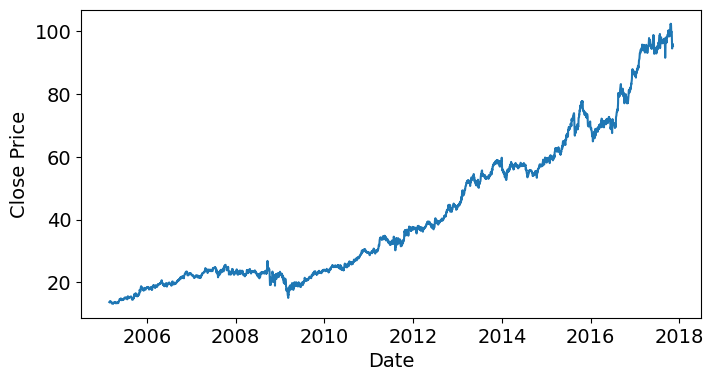

In [7]:
plt.plot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [8]:
df_close =np.log(df['Close'])
train_data, test_data = df_close[:int(0.9*len(df_close))], df_close[int(0.9*len(df_close)):]


In [9]:
print(adf_test(train_data))
print("-------------"*4)
print(kpss_test(train_data))

Fail to reject the null hypothesis (HO), 
the data is not stationary.
ADF: Test statistic       -0.737048
p value                    0.836918
# of Lags                 15.000000
# of Observations       2864.000000
Critical Value (1%)       -3.432635
Critical Value (5%)       -2.862550
Critical Value (10%)      -2.567307
dtype: float64
----------------------------------------------------
Reject the null hypothesis (H0), 
the data is not stationary.
KPSS: Test statistic      8.63507
p value                   0.01000
# of Lags                31.00000
Critical Value (10%)      0.34700
Critical Value (5%)       0.46300
Critical Value (2.5%)     0.57400
Critical Value (1%)       0.73900
dtype: float64


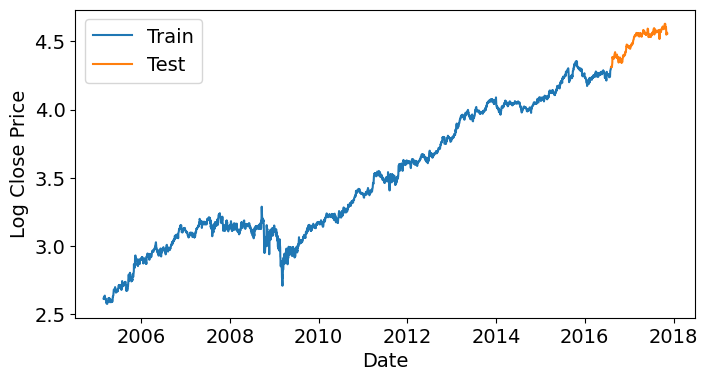

In [10]:
plt.xlabel('Date')
plt.ylabel('Log Close Price')
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.legend()
plt.show()

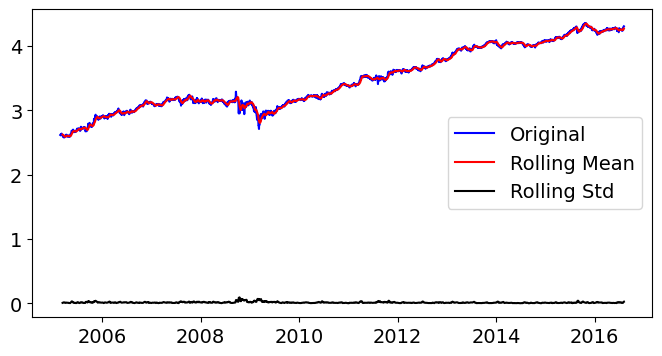

In [11]:
rolmean = train_data.rolling(window=12).mean()
rolstd = train_data.rolling(window=12).std()
plt.plot(train_data, label='Original', color='blue')
plt.plot(rolmean, label='Rolling Mean', color='red')
plt.plot(rolstd, label='Rolling Std', color='black')
plt.legend()
plt.show()


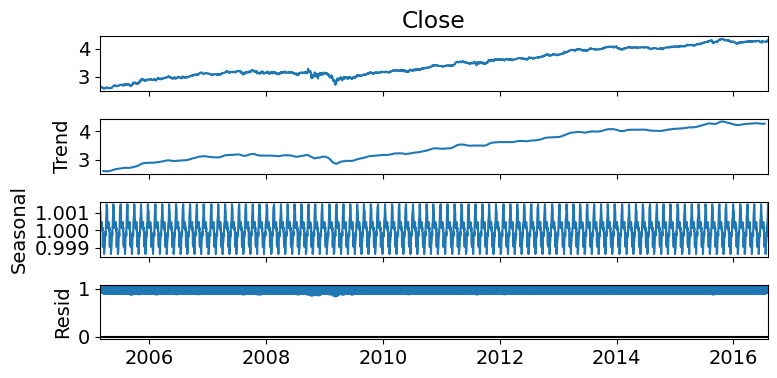

In [12]:
decompose_result = seasonal_decompose(train_data, model='multiplicative', period=30)
decompose_result.plot()
plt.show()

In [13]:
print(adf_test(train_data))
print("-------------"*4)
print(kpss_test(train_data))

Fail to reject the null hypothesis (HO), 
the data is not stationary.
ADF: Test statistic       -0.737048
p value                    0.836918
# of Lags                 15.000000
# of Observations       2864.000000
Critical Value (1%)       -3.432635
Critical Value (5%)       -2.862550
Critical Value (10%)      -2.567307
dtype: float64
----------------------------------------------------
Reject the null hypothesis (H0), 
the data is not stationary.
KPSS: Test statistic      8.63507
p value                   0.01000
# of Lags                31.00000
Critical Value (10%)      0.34700
Critical Value (5%)       0.46300
Critical Value (2.5%)     0.57400
Critical Value (1%)       0.73900
dtype: float64


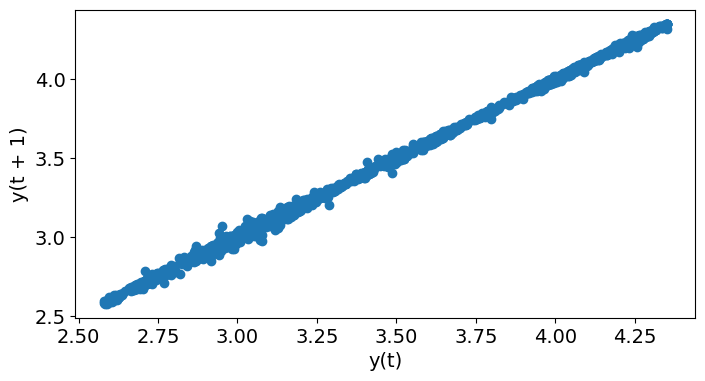

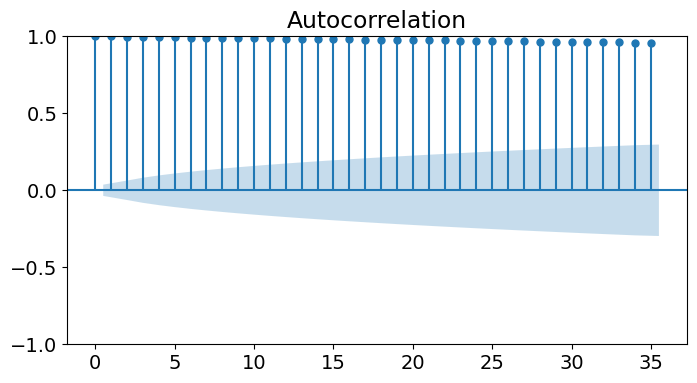

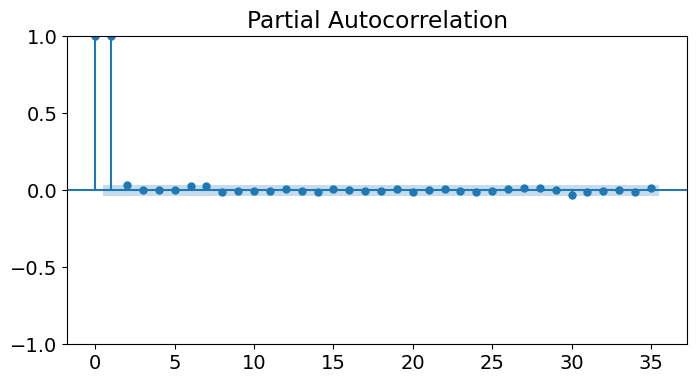

In [14]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
pd.plotting.lag_plot(train_data) 
plt.show()
plot_acf(train_data)
plt.show()
plot_pacf(train_data)
plt.show()

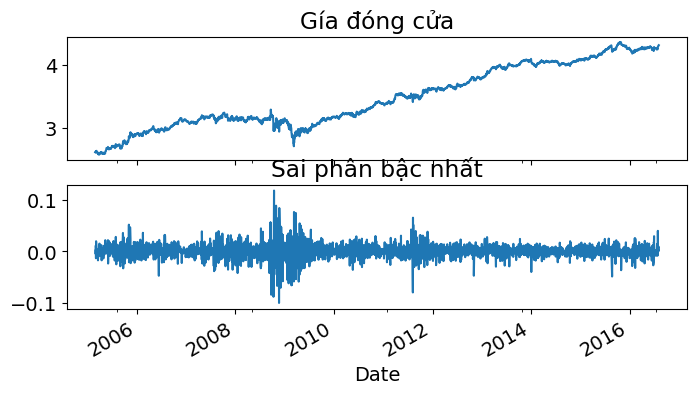

In [15]:
diff =train_data.diff(1).dropna() # Differencing to make the series stationary
#  Biểu đồ thể hiện dữ liệu ban đầu và sau khi lấy sai phân
fig,ax = plt.subplots(2, sharex="all") 
train_data.plot(ax=ax[0], title="Gía đóng cửa")
diff.plot(ax=ax[1], title="Sai phân bậc nhất")
plt.show()

In [16]:
print(adf_test(diff))
print("-------------"*4)
print(kpss_test(diff))

Reject the null hypothesis (H0), 
the data is stationary.
ADF: Test statistic    -1.597475e+01
p value                 6.940782e-29
# of Lags               1.400000e+01
# of Observations       2.864000e+03
Critical Value (1%)    -3.432635e+00
Critical Value (5%)    -2.862550e+00
Critical Value (10%)   -2.567307e+00
dtype: float64
----------------------------------------------------
Fail to reject the null hypothesis (HO), 
the data is stationary.
KPSS: Test statistic      0.058523
p value                   0.100000
# of Lags                25.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-16550.100, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-16511.067, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-16545.696, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-16547.662, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-16507.830, Time=0.07 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-16557.262, Time=0.48 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-16546.796, Time=0.25 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-16546.834, Time=0.23 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-16545.729, Time=0.70 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-16544.634, Time=1.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-16545.077, Time=0.45 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-16536.028, Time=0.23 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-16547.268, Time=0.37 sec

Best model:  ARIMA(1,1,2)(0,0,0)[0] intercept
Total fit time: 5.374 seco

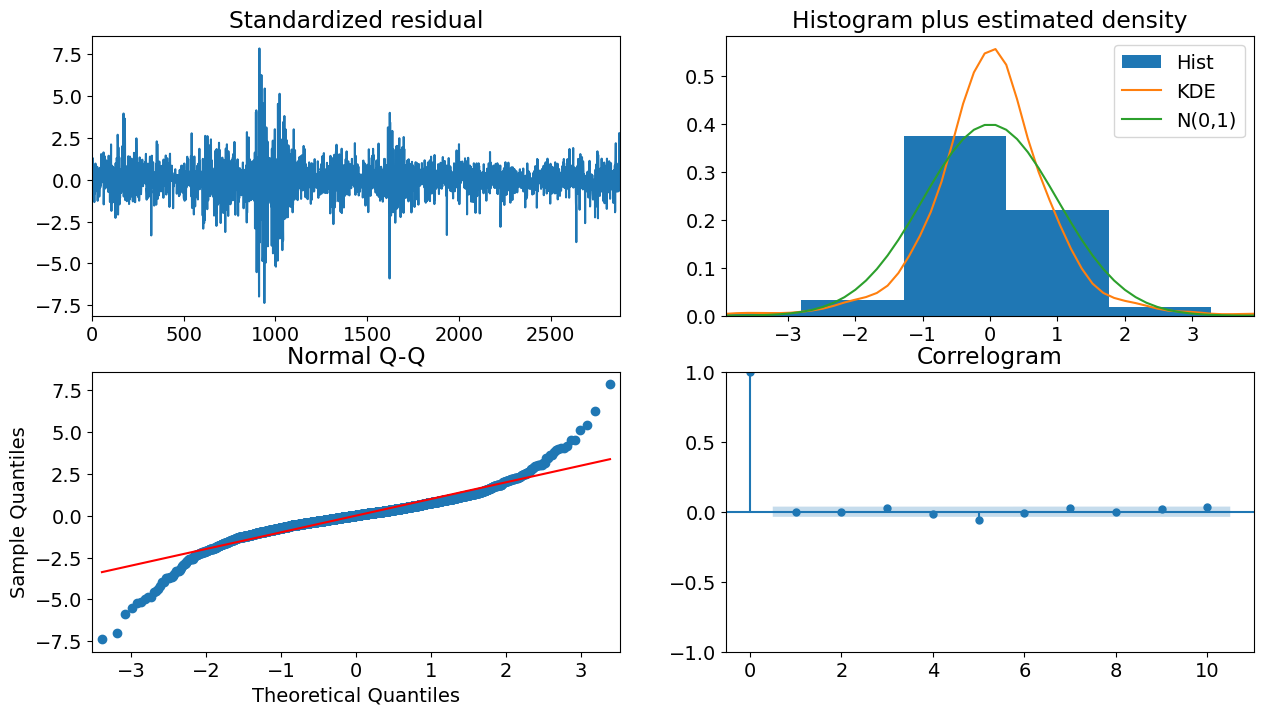

In [17]:
stepwise_model = auto_arima(train_data, trace=True, suppress_warnings=True)
print(stepwise_model.summary())
stepwise_model.plot_diagnostics(figsize=(15, 8))
plt.show()

In [19]:
# B6e - Fit mô hình
model = ARIMA(train_data, order=(1, 1, 2), trend='t')
fitted = model.fit()
print(fitted.summary())


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2880
Model:                 ARIMA(1, 1, 2)   Log Likelihood                8260.497
Date:                Thu, 04 Jun 2026   AIC                         -16510.994
Time:                        16:23:20   BIC                         -16481.168
Sample:                             0   HQIC                        -16500.243
                               - 2880                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0006   5.84e-05      9.765      0.000       0.000       0.001
ar.L1          0.9696      0.005    199.635      0.000       0.960       0.979
ma.L1         -1.1023      0.012    -95.717      0.0

In [20]:
# B6f Dự báo
fc = fitted.get_forecast(len(test_data))
fc_values = fc.predicted_mean
fc_values.index = test_data.index
conf = fc.conf_int(alpha=0.05) # 95% conf
lower_series = conf['lower Close']
lower_series.index = test_data.index
upper_series = conf['upper Close']
upper_series.index = test_data.index

In [21]:
# B7a - Đánh giá hiệu suất mô hình
mse = mean_squared_error(test_data, fc_values)
print('Test MSE: %.3f' % mse)
rmse = np.sqrt(mse)
print('Test RMSE: {:.3f}' .format(rmse))

Test MSE: 0.011
Test RMSE: 0.106


In [22]:
# B7b - Calculate RMSE for baseline
baseline_prediction = np.full_like(test_data, train_data.mean()) # or median
baseline_rmse = np.sqrt(mean_squared_error(test_data, baseline_prediction))

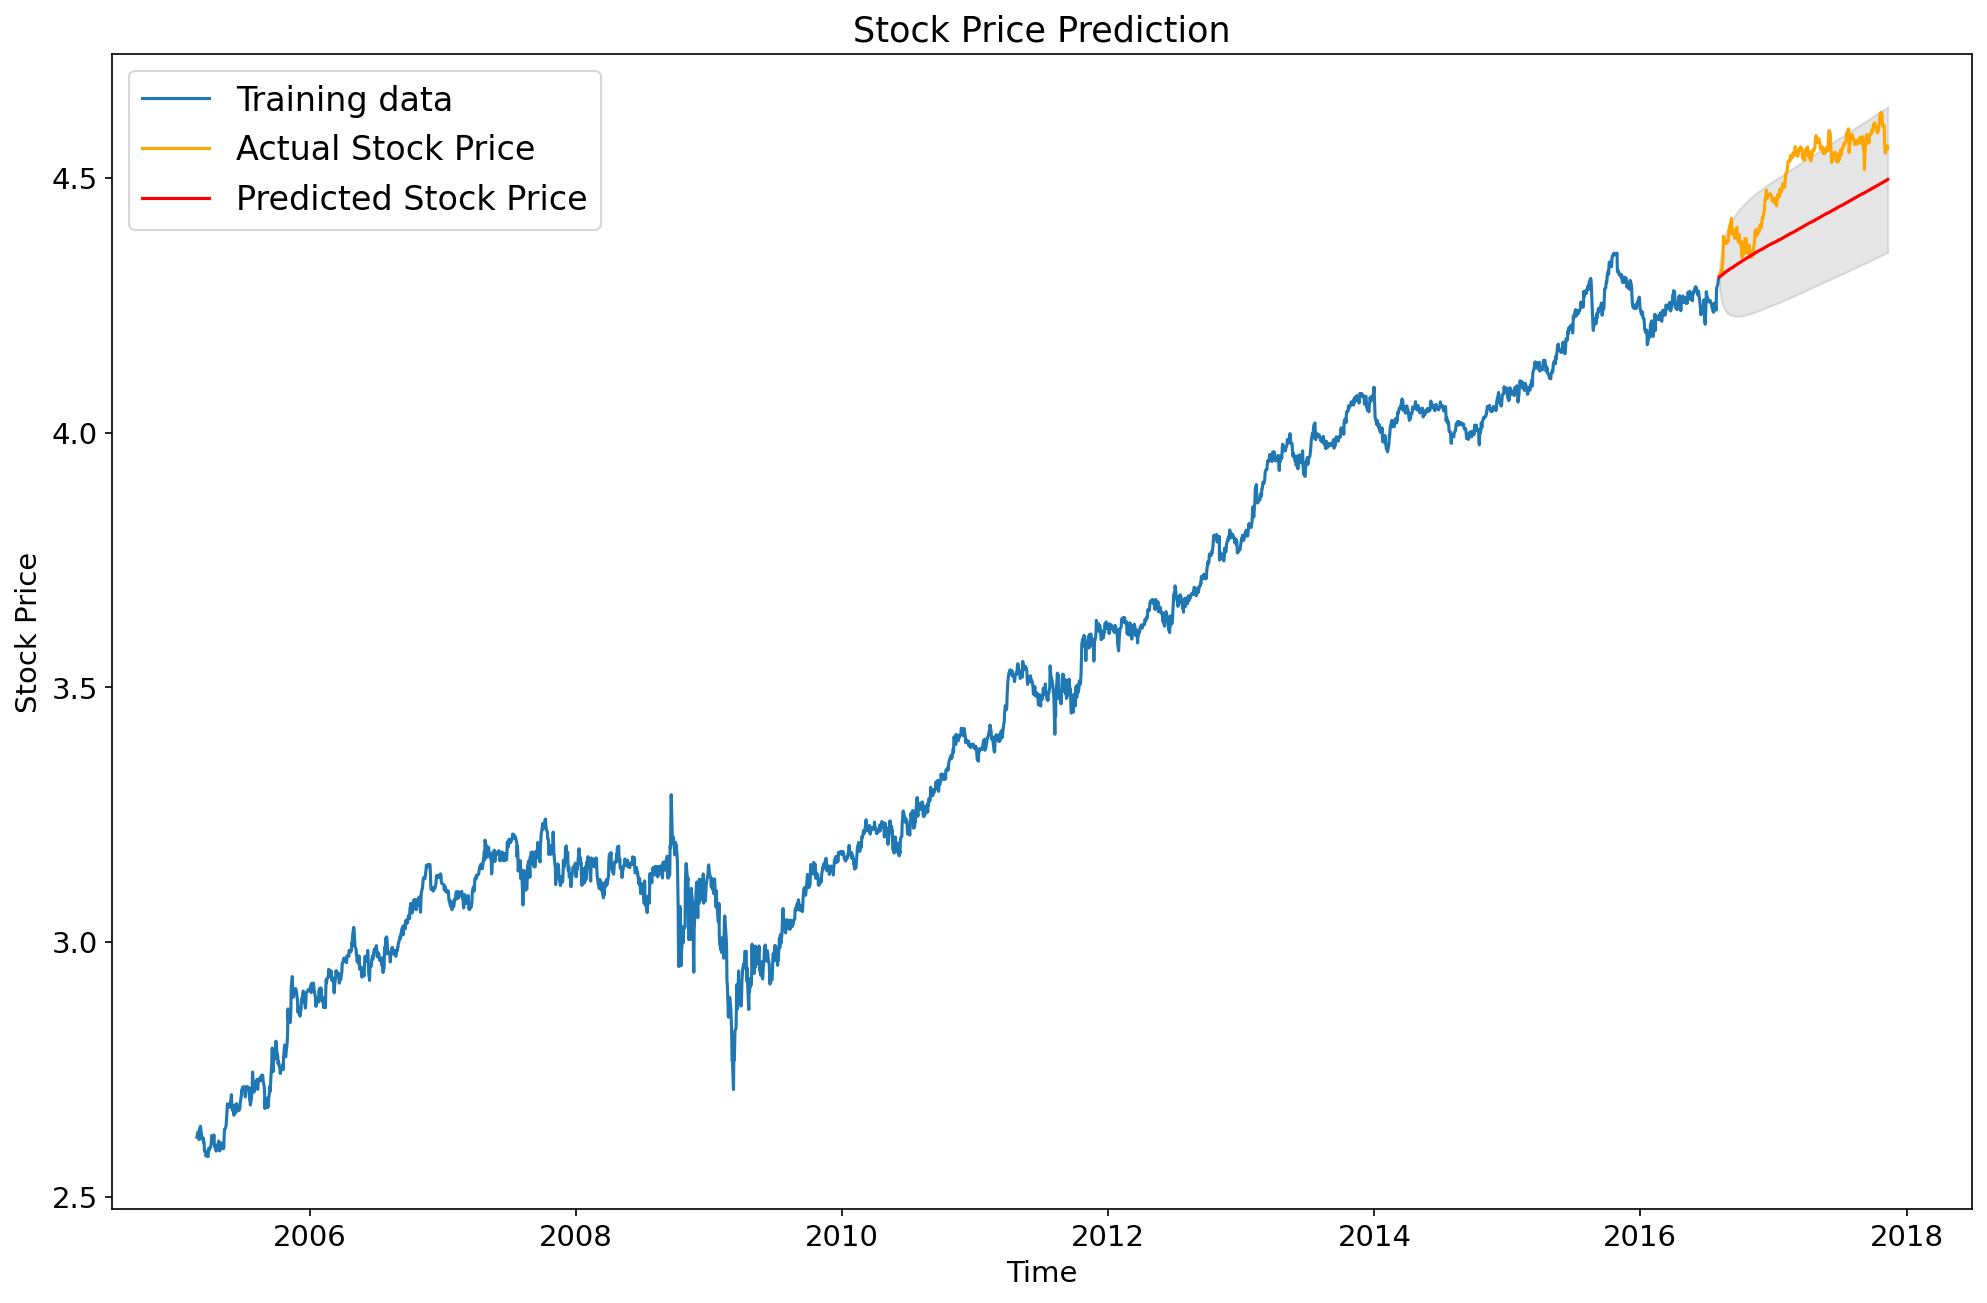

In [23]:
# B7c - Plot actual vs predicted values
plt.figure(figsize=(16, 10), dpi=150)
plt.plot(train_data, label='Training data')
plt.plot(test_data, color='orange', label='Actual Stock Price')
# plt.plot(fc_series, color='red', label='Predicted Stock Price')
plt.plot(fc_values, color='red', label='Predicted Stock Price')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.10)
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend(loc='upper left', fontsize=16)
plt.show()

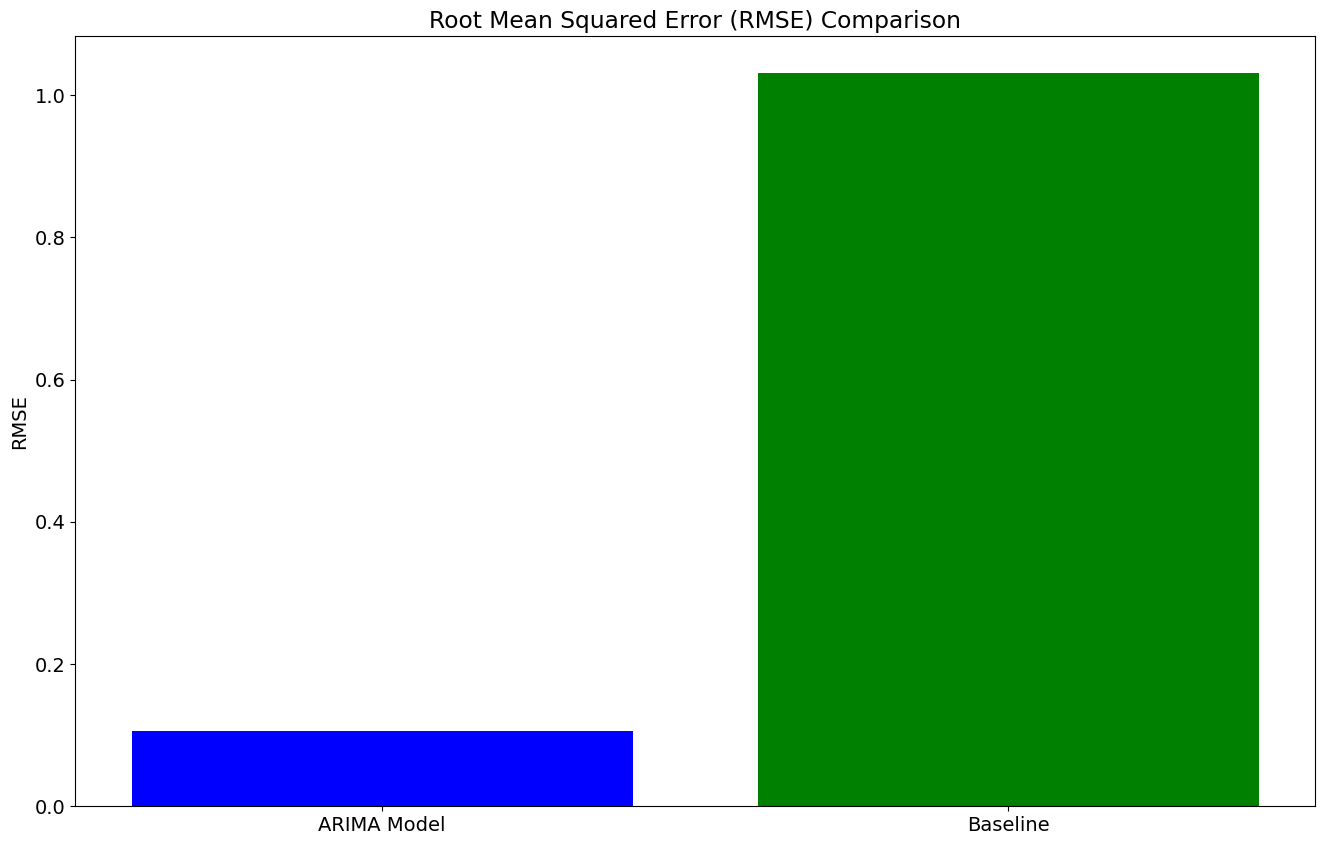

ARIMA Model RMSE: 0.11
Baseline RMSE: 1.03


In [24]:
# B7d - Visualize RMSE comparison
plt.figure(figsize=(16, 10))
plt.bar(['ARIMA Model', 'Baseline'], [rmse, baseline_rmse], color=['blue', 'green'])
plt.title('Root Mean Squared Error (RMSE) Comparison')
plt.ylabel('RMSE')
plt.show()

print('ARIMA Model RMSE: {:.2f}'.format(rmse))
print('Baseline RMSE: {:.2f}'.format(baseline_rmse))